Starter Code

In [175]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


Helper Function

In [176]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None, aug=False):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0) if not aug else model.fit(x_tr,
        validation_data=(x_val_C, to_categorical(y_val,10)),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb, verbose=0
    )

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

1A. Normalization Comparison

## Build Baseline Model for CNN

In [177]:
# build baseline model for CNN
def BaselineCNN():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32,(3,3), activation= "relu", padding= "same"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,(3,3), activation= "relu", padding= "same"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation= "relu"),
        layers.Dense(10, activation= "softmax")
    ])
    return model

## Experiment A: No normalization

In [178]:
# Experiment A: No normalization
x_train_A = x_train
x_val_A = x_val
x_test_A = x_test

model_A = BaselineCNN()
model_A.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Experiment A: No normalization")
hist_A, acc_A, loss_A, time_A = train_and_evaluate(
    model_A, x_train_A, y_train, x_val_A, y_val, x_test_A, y_test
)


Experiment A: No normalization
Test Acc: 0.5550 | Test Loss: 3.2853 | Time:48.2s


## Experiment B: Min-Max normalization

In [179]:
# Experiment B: Min-Max normalization
x_train_B = x_train / 255
x_val_B = x_val / 255
x_test_B = x_test / 255

model_B = BaselineCNN()
model_B.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Experiment B: Min-Max normalization")
hist_B, acc_B, loss_B, time_B = train_and_evaluate(
    model_B, x_train_B, y_train, x_val_B, y_val, x_test_B, y_test
)


Experiment B: Min-Max normalization
Test Acc: 0.6668 | Test Loss: 1.3577 | Time:46.8s


## Experiment C: Standardization per-channel

In [180]:
# Experiment C: Standardization per-channel
mean = np.mean(x_train, axis= (0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))
x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

model_C = BaselineCNN()
model_C.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Experiment C: Standardization per-channel")
hist_C, acc_C, loss_C, time_C = train_and_evaluate(
    model_C, x_train_C, y_train, x_val_C, y_val, x_test_C, y_test
)

Experiment C: Standardization per-channel
Test Acc: 0.6673 | Test Loss: 2.2148 | Time:49.3s


## Plot the Loass and Accuracy Results

In [181]:
print(hist_A.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


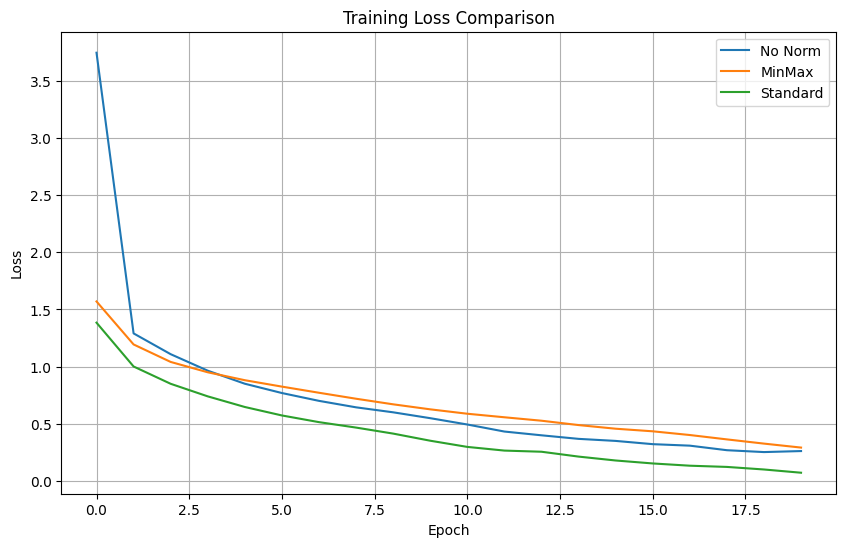

In [182]:
# training loss curves
plot_curves(
    histories=[hist_A,hist_B,hist_C],
    labels=['No Norm', 'MinMax', 'Standard'],
    metric='loss',
    title='Training Loss Comparison',
    ylabel='Loss'
)


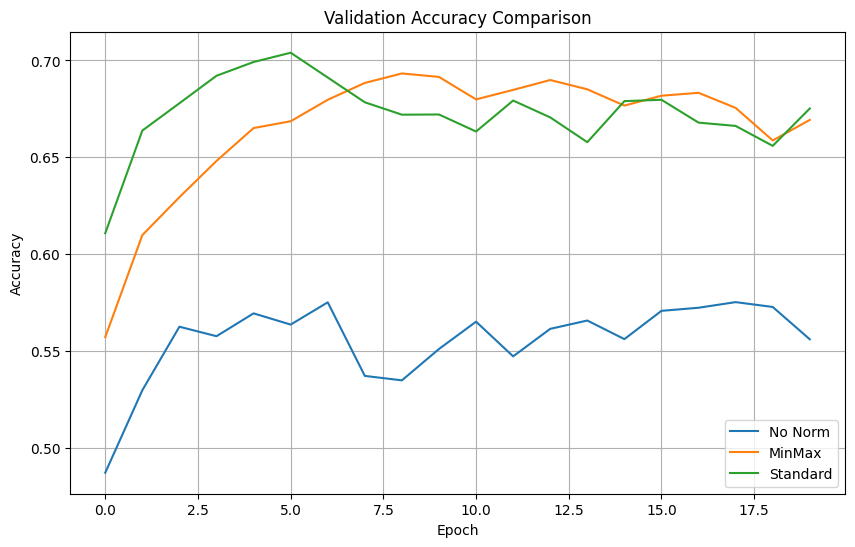

In [183]:
# validation accuracy curves
plot_curves(
    histories=[hist_A, hist_B, hist_C],
    labels=['No Norm', 'MinMax', 'Standard'],
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

## Results Table

In [184]:
# results table
acc_A_train = hist_A.history['accuracy'][-1]
acc_B_train = hist_B.history['accuracy'][-1]
acc_C_train = hist_C.history['accuracy'][-1]

acc_A_val = hist_A.history['val_accuracy'][-1]
acc_B_val = hist_B.history['val_accuracy'][-1]
acc_C_val = hist_C.history['val_accuracy'][-1]

loss1_A = hist_A.history['loss'][0]
loss1_B = hist_B.history['loss'][0]
loss1_C = hist_C.history['loss'][0]

print("Results Table")
print(f"None         | Train Acc: {acc_A_train:.4f} | Val Acc: {acc_A_val:.4f} | Test Acc: {acc_A:.4f} | Loss@1: {loss1_A:.4f}")
print(f"Min-Max      | Train Acc: {acc_B_train:.4f} | Val Acc: {acc_B_val:.4f} | Test Acc: {acc_B:.4f} | Loss@1: {loss1_B:.4f}")
print(f"Standardized | Train Acc: {acc_C_train:.4f} | Val Acc: {acc_C_val:.4f} | Test Acc: {acc_C:.4f} | Loss@1: {loss1_C:.4f}")

Results Table
None         | Train Acc: 0.9136 | Val Acc: 0.5560 | Test Acc: 0.5550 | Loss@1: 3.7462
Min-Max      | Train Acc: 0.9021 | Val Acc: 0.6693 | Test Acc: 0.6668 | Loss@1: 1.5703
Standardized | Train Acc: 0.9758 | Val Acc: 0.6752 | Test Acc: 0.6673 | Loss@1: 1.3847


# **1B. Data Augmentation**

## First Experimnet: Without Augmentation

In [185]:
model_NoAug = BaselineCNN()
model_NoAug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [186]:
hist_NoAug, acc_NoAug, loss_NoAug, time_NoAug = train_and_evaluate(
    model_NoAug, x_train_C, y_train, x_val_C, y_val, x_test_C, y_test, epochs=40, batch_size=128
)

Test Acc: 0.6608 | Test Loss: 3.5782 | Time:88.4s


## Second Experimnet: With Augmentation

In [187]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
rotation_range=15,
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True,
zoom_range=0.1
)

datagen.fit(x_train_C)

In [188]:
model_Aug = BaselineCNN()
model_Aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [191]:
hist_Aug, acc_Aug, loss_Aug, time_Aug = train_and_evaluate(
    model_Aug,
    datagen.flow(x_train_C, to_categorical(y_train,10), batch_size=128),
    y_train,
    x_val_C,
    y_val,
    x_test_C,
    y_test,
    epochs=40,
    batch_size=128,
    aug=True
)

Test Acc: 0.7832 | Test Loss: 0.7140 | Time:928.5s


## Plot the Train and Val Accuracy

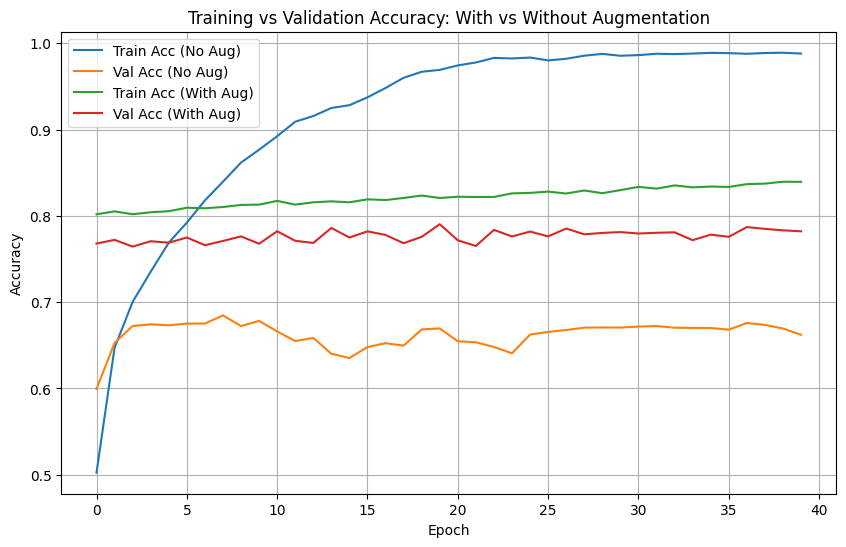

In [192]:
plt.figure(figsize=(10, 6))
plt.plot(hist_NoAug.history['accuracy'],     label='Train Acc (No Aug)')
plt.plot(hist_NoAug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(hist_Aug.history['accuracy'],       label='Train Acc (With Aug)')
plt.plot(hist_Aug.history['val_accuracy'],   label='Val Acc (With Aug)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy: With vs Without Augmentation')
plt.legend()
plt.grid(True)
plt.show()

## Which one overfits less?

In [193]:
acc_Aug_train = hist_Aug.history['accuracy'][-1]
acc_NoAug_train = hist_NoAug.history['accuracy'][-1]

acc_Aug_val = hist_Aug.history['val_accuracy'][-1]
acc_NoAug_val = hist_NoAug.history['val_accuracy'][-1]

gap_NoAug = hist_NoAug.history['accuracy'][-1] - hist_NoAug.history['val_accuracy'][-1]
gap_Aug = hist_Aug.history['accuracy'][-1] - hist_Aug.history['val_accuracy'][-1]


print(f"Without Aug → Train: {hist_NoAug.history['accuracy'][-1]:.4f} | Val: {hist_NoAug.history['val_accuracy'][-1]:.4f} | Gap: {gap_NoAug:.4f}")
print(f"With Aug    → Train: {hist_Aug.history['accuracy'][-1]:.4f} | Val: {hist_Aug.history['val_accuracy'][-1]:.4f} | Gap: {gap_Aug:.4f}")
print(f"\n→ {'With Aug' if gap_Aug < gap_NoAug else 'Without Aug'} overfits less (smaller gap)")

Without Aug → Train: 0.9880 | Val: 0.6622 | Gap: 0.3259
With Aug    → Train: 0.8394 | Val: 0.7821 | Gap: 0.0573

→ With Aug overfits less (smaller gap)
